In [2]:
import pyproj
import rioxarray # noqa
import xarray as xr
from datetime import datetime
from shapely.geometry import box
from pystac_client import Client
from odc import stac as odc_stac

In [3]:
# Define the API URL
api_url = "https://stac.eodc.eu/api/v1"

# Define the STAC collection ID
collection_id = "GFM"

eodc_catalog = Client.open(api_url)



In [12]:
# Define the area of interest (AOI) as a bounding box
# aoi = box(9.063232,30.562261,15.677490,33.403931)
aoi = box(10.283203,31.842566,12.598572,33.330528)


# Define the time range for the search
time_range = (datetime(2026, 3, 9), datetime(2026, 3, 10))

In [13]:
# Perform a search in the catalog with the specified parameters
search = eodc_catalog.search(
    max_items=1000,             # Maximum number of items to return
    collections=collection_id,  # The collection to search within
    intersects=aoi,             # The area of interest
    datetime=time_range         # The time range for the search
)

# Collect the found items into an item collection
items = search.item_collection()

print(f"On EODC we found {len(items)} items for the given search query")

On EODC we found 2 items for the given search query


In [14]:
for item in items:
    print(item.id)

ENSEMBLE_FLOOD_20260309T050631_VV_AF020M_E045N084T3
ENSEMBLE_FLOOD_20260309T050606_VV_AF020M_E045N084T3


In [15]:
crs = pyproj.CRS.from_wkt(items[0].properties["proj:wkt2"])
# Set the resolution of the data
resolution = items[0].properties['gsd']

# Specify the bands to load
bands = ["ensemble_flood_extent"]

In [16]:
gf = odc_stac.load(
    items, 
    bbox=aoi.bounds,   # Define the bounding box for the area of interest
    crs=crs,   # Set the coordinate reference system
    bands=bands,   # Specify the bands to load
    resolution=resolution,   # Set the resolution of the data
    dtype='uint8',   # Define the data type
    groupby="solar_day",
    # fail_on_error=False,
)

gf

<xarray.Dataset> Size: 105MB
Dimensions:                (y: 8843, x: 11799, time: 1)
Coordinates:
  * y                      (y) float64 71kB 8.771e+06 8.771e+06 ... 8.594e+06
  * x                      (x) float64 94kB 4.531e+06 4.531e+06 ... 4.767e+06
    spatial_ref            int32 4B 0
  * time                   (time) datetime64[ns] 8B 2026-03-09T05:06:06
Data variables:
    ensemble_flood_extent  (time, y, x) uint8 104MB 255 255 255 255 ... 0 0 0 0

In [ ]:
data = gf["ensemble_flood_extent"]
result = data.where((data != 255) & (data != 0)).sum(dim="time")

# Convert the result to binary (1 where the sum is greater than 0, otherwise 0)
# and set the data type to uint8 
result = xr.where(result > 0, 1, 0).astype("uint8")

In [23]:
result.rio.to_raster("max_flood_libya.tif", compress="LZW")

result

<xarray.DataArray 'ensemble_flood_extent' (y: 8843, x: 11799)> Size: 104MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(8843, 11799), dtype=uint8)
Coordinates:
  * y            (y) float64 71kB 8.771e+06 8.771e+06 ... 8.594e+06 8.594e+06
  * x            (x) float64 94kB 4.531e+06 4.531e+06 ... 4.767e+06 4.767e+06
    spatial_ref  int32 4B 0

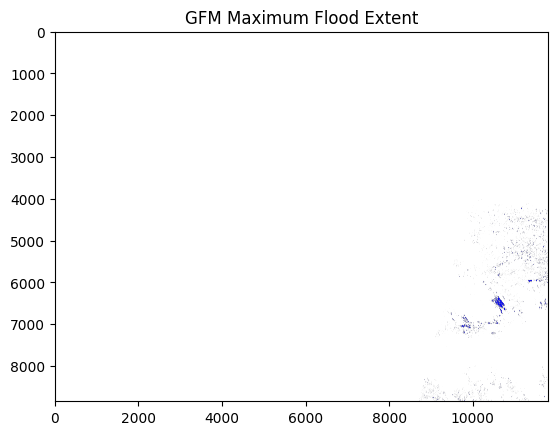

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['none', 'blue'])


plt.figure()
plt.imshow(result, cmap=cmap)
plt.title("GFM Maximum Flood Extent")
plt.show()